In [1]:
import sccoda
import celltypist
import scanpy as sc
import pandas as pd
import os
import scipy
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy.stats import ttest_ind, mannwhitneyu, spearmanr
import numpy as np

/data/homezvol3/asdalvi/miniconda3/envs/single_cell/lib/python3.11/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [2]:
# adata.obs.to_csv("/pub/asdalvi/CHIP_liver/male_6_month_mice_data/processed_merged_adata/male_6_month_metadata_adata.csv")

In [3]:
adata = sc.read_h5ad("/pub/asdalvi/CHIP_liver/data/male_6_month_mice_data/processed_merged_adata/preprocessed_male_6_month_adata.h5ad")

In [56]:
counts = adata.obs.groupby(['condition_full']).size()

In [3]:
adata.obs['celltypist_pred'].value_counts()

celltypist_pred
B cells                 22045
CTLs                     9835
Naive CD8                3978
Treg                     1842
Monocytes                1780
Teff memory              1665
Trans Monocytes 1        1616
pDCs                     1305
Patrolling Monocytes     1265
T helper                 1143
cDC2s                    1119
NK                        945
NKT                       780
cDC1s                     552
ILCs                      435
Gd                        400
Naive CD4                 367
Mig cDCs                  195
CV and Capsule            119
Name: count, dtype: int64

## Investigate if CTL Proportions are Significant

In [4]:
def calculate_proportions(df, sample_col='orig.ident', condition_col='condition', cell_type_col='celltypist_pred'):
    counts = df.groupby([sample_col, condition_col, cell_type_col], observed=True).size().reset_index(name='count')
    
    pivot_df = counts.pivot_table(index=[sample_col, condition_col], 
                                  columns=cell_type_col, 
                                  values='count', 
                                  fill_value=0)
    
    props = pivot_df.div(pivot_df.sum(axis=1), axis=0)
    
    return props.reset_index()

In [10]:
proportions = calculate_proportions(adata.obs)

In [20]:
from scipy.stats import ranksums
from statsmodels.stats.multitest import multipletests
from itertools import combinations

target_cell_type = 'CTLs'
conditions = proportions['condition'].unique()
pairs = list(combinations(conditions, 2))

results = []

for cond1, cond2 in pairs:
    data1 = proportions[proportions['condition'] == cond1][target_cell_type]
    data2 = proportions[proportions['condition'] == cond2][target_cell_type]
    
    stat, p_val = ranksums(data1, data2)
    
    results.append({
        'Comparison': f"{cond1} vs {cond2}",
        'Cell Type': target_cell_type,
        'p-value': p_val,
        'Mean_1': data1.mean(),
        'Mean_2': data2.mean()
    })

ctl_stats = pd.DataFrame(results)
ctl_stats['p-adj (6 tests)'] = multipletests(ctl_stats['p-value'], method='fdr_bh')[1]

print(ctl_stats)

  Comparison Cell Type   p-value    Mean_1    Mean_2  p-adj (6 tests)
0   tn vs tw      CTLs  0.772830  0.277956  0.302928         0.772830
1   tn vs wn      CTLs  0.043308  0.277956  0.071445         0.064962
2   tn vs ww      CTLs  0.020921  0.277956  0.029959         0.041843
3   tw vs wn      CTLs  0.020921  0.302928  0.071445         0.041843
4   tw vs ww      CTLs  0.020921  0.302928  0.029959         0.041843
5   wn vs ww      CTLs  0.148915  0.071445  0.029959         0.178698


In [21]:
ctl_stats

,Comparison,Cell Type,p-value,Mean_1,Mean_2,p-adj (6 tests)
0,tn vs tw,CTLs,0.772830,0.277956,0.302928,0.772830
1,tn vs wn,CTLs,0.043308,0.277956,0.071445,0.064962
2,tn vs ww,CTLs,0.020921,0.277956,0.029959,0.041843
3,tw vs wn,CTLs,0.020921,0.302928,0.071445,0.041843
4,tw vs ww,CTLs,0.020921,0.302928,0.029959,0.041843
5,wn vs ww,CTLs,0.148915,0.071445,0.029959,0.178698


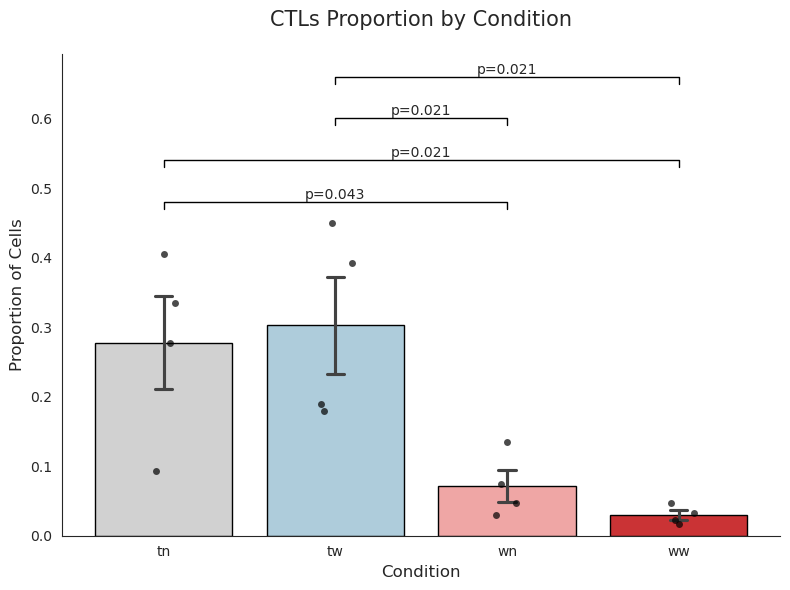

<Figure size 640x480 with 0 Axes>

In [25]:
conditions = ['tn', 'tw', 'wn', 'ww']
pairs = list(combinations(conditions, 2))

# calculate pairwise wilcoxon p vals
stats_results = []
for c1, c2 in pairs:
    group1 = proportions[proportions['condition'] == c1]['CTLs']
    group2 = proportions[proportions['condition'] == c2]['CTLs']
    _, p_val = ranksums(group1, group2)
    stats_results.append(((c1, c2), p_val))


plt.figure(figsize=(8, 6))
sns.set_style("white")


palette = {'tn': '#d1d1d1', 'tw': '#a6cee3', 'wn': '#fb9a99', 'ww': '#e31a1c'}

# bar plot with error bars 
ax = sns.barplot(
    data=proportions, 
    x='condition', 
    y='CTLs', 
    order=conditions, 
    palette=palette,
    capsize=.1,
    errorbar='se',
    edgecolor='black'
)


sns.stripplot(
    data=proportions, 
    x='condition', 
    y='CTLs', 
    order=conditions, 
    color='black', 
    alpha=0.7, 
    jitter=True
)


max_y = proportions['CTLs'].max()
y_pos = max_y + 0.02
step = 0.06

for (c1, c2), p in stats_results:
    if p < 0.05:
        x1, x2 = conditions.index(c1), conditions.index(c2)
        # draw the bracket
        plt.plot([x1, x1, x2, x2], [y_pos, y_pos + 0.01, y_pos + 0.01, y_pos], lw=1, c='black')
        
        # determine annotation text
        if p < 0.001: label = "***"
        elif p < 0.01: label = "**"
        else: label = f"p={p:.3f}"
        
        plt.text((x1 + x2) * 0.5, y_pos + 0.01, label, ha='center', va='bottom', fontsize=10)
        y_pos += step

plt.title('CTLs Proportion by Condition', fontsize=15, pad=20)
plt.ylabel('Proportion of Cells', fontsize=12)
plt.xlabel('Condition', fontsize=12)
sns.despine()

plt.tight_layout()
plt.show()
plt.savefig('/pub/asdalvi/CHIP_liver/figures/CTL_condition_proportions.png')

## Correlation Between Cell Type Proportions and HCC Score for Mice Samples

In [6]:
hcc_scores = {
    "wn80": 0, "wn81": 0, "wn83": 0, "wn84": 0,
    "ww95": 2, "ww96": 1, "ww99": 2, "ww101": 4,
    "tn80": 0, "tn82": 0, "tn84": 0, "tn85": 0,
    "tw99": 5, "tw100": 4, "tw102": 6, "tw108": 2
}

cell_props = pd.crosstab(adata.obs['orig.ident'], adata.obs['celltypist_pred'], normalize='index') # normalizea cross index

In [37]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,celltypist_pred,conf_score,condition,HCC_score,condition_full
tn80_AAACCATTCCCGCACT-1,tn80,11848,3633,3633,11848.0,137.0,1.156313,CTLs,0.999361,tn,0,tet2_normal
tn80_AAACCATTCCTGTCCA-1,tn80,11989,3323,3323,11989.0,137.0,1.142714,B cells,1.000000,tn,0,tet2_normal
tn80_AAACCATTCGATCCAA-1,tn80,10055,3068,3068,10055.0,59.0,0.586773,NK,0.928007,tn,0,tet2_normal
tn80_AAACCGCTCACCTCTG-1,tn80,27152,5440,5440,27152.0,303.0,1.115940,pDCs,1.000000,tn,0,tet2_normal
tn80_AAACCGCTCACTAGGC-1,tn80,13971,3868,3868,13971.0,176.0,1.259752,CTLs,0.999808,tn,0,tet2_normal
...,...,...,...,...,...,...,...,...,...,...,...,...
ww99_TGTCTCACAATACTCT-1,ww99,4613,2039,2039,4613.0,78.0,1.690874,Teff memory,0.995930,ww,2,wildtype_western
ww99_TGTCTCACAGCTCTGT-1,ww99,8019,3058,3058,8019.0,91.0,1.134805,Trans Monocytes 1,0.962004,ww,2,wildtype_western
ww99_TGTCTTGCAGGATACT-1,ww99,17239,4248,4248,17239.0,151.0,0.875921,Patrolling Monocytes,0.999557,ww,2,wildtype_western
ww99_TGTCTTGCATTACTCG-1,ww99,8399,2909,2909,8399.0,116.0,1.381117,CTLs,0.999585,ww,2,wildtype_western


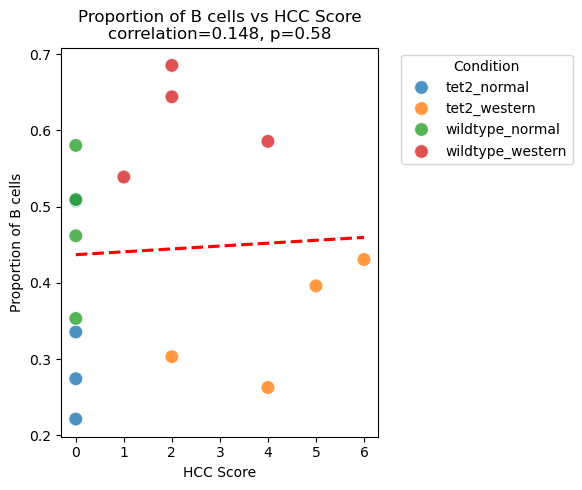

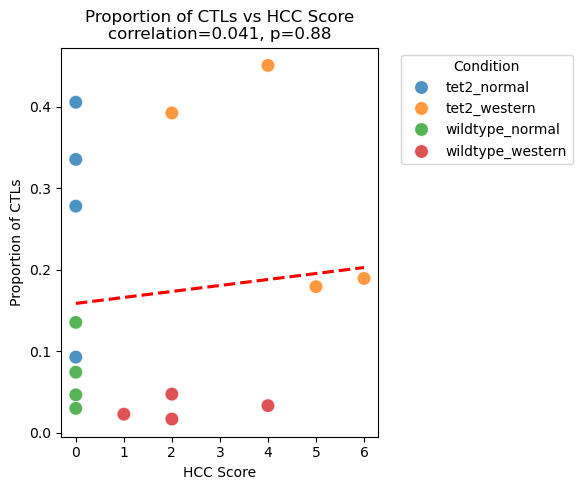

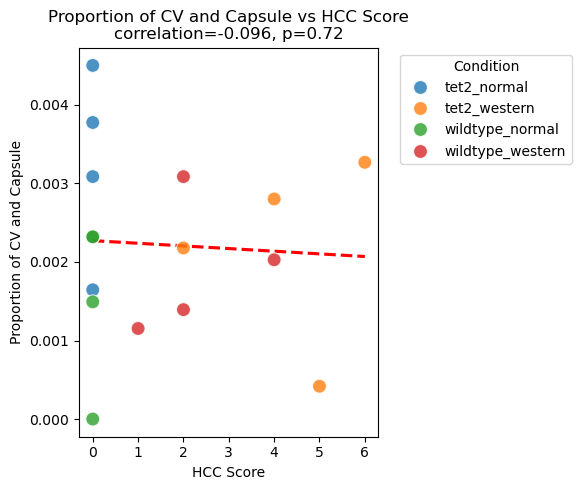

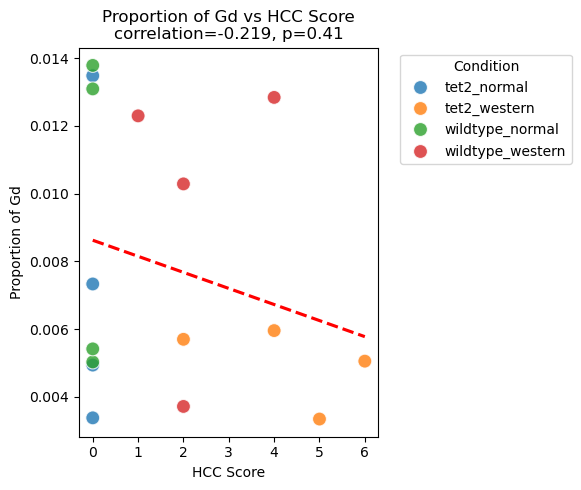

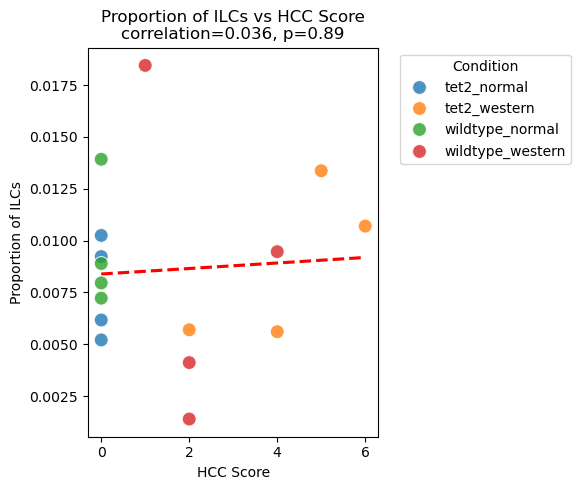

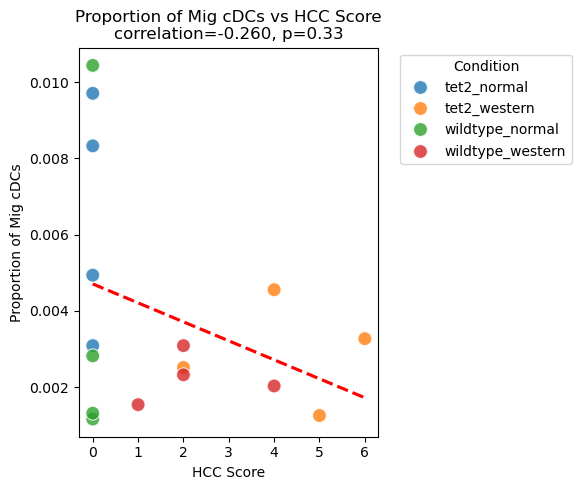

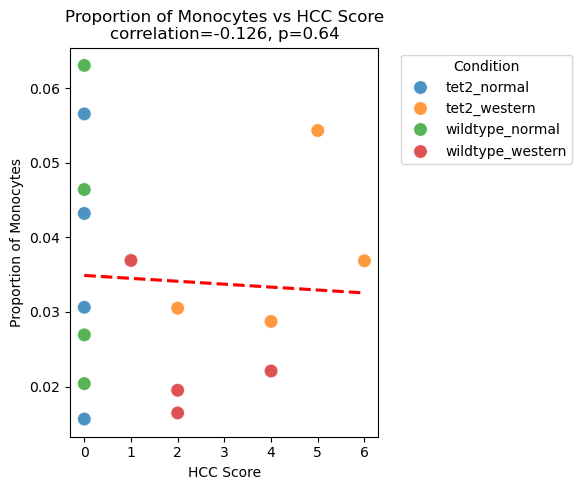

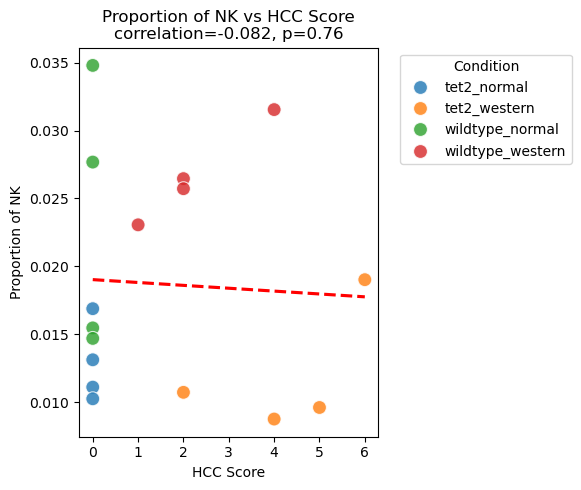

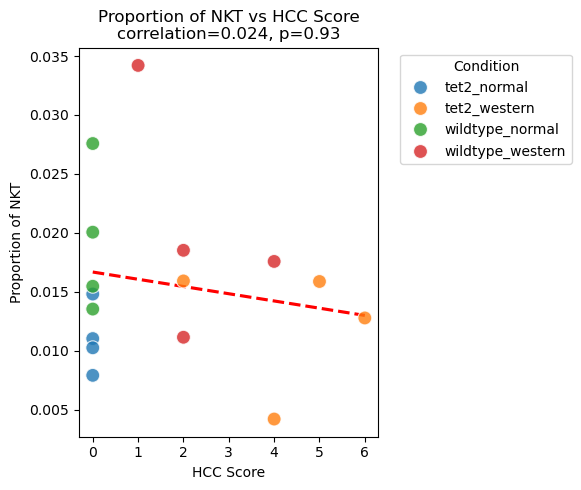

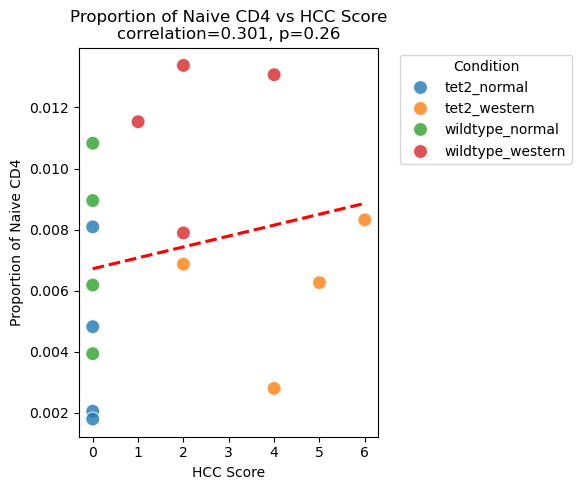

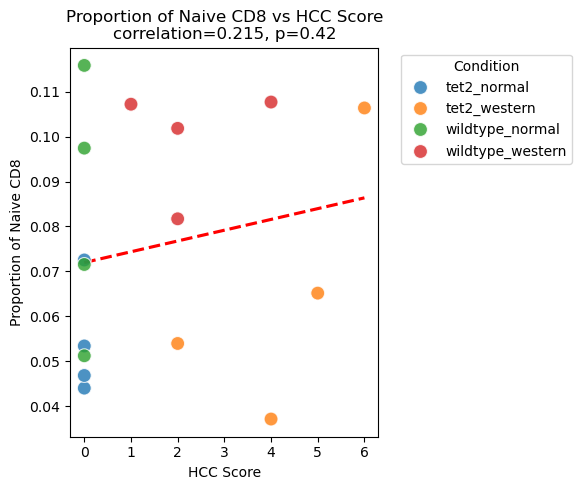

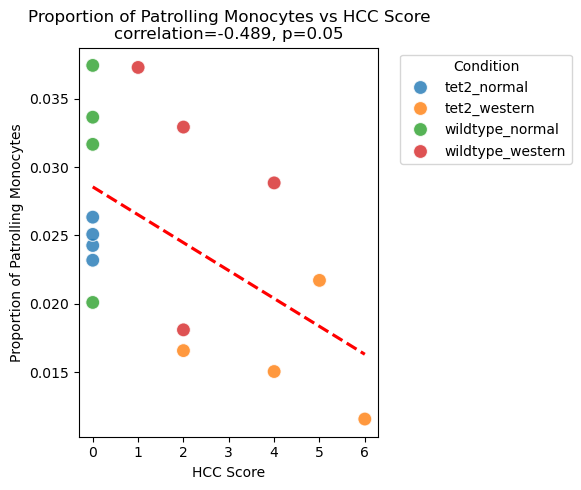

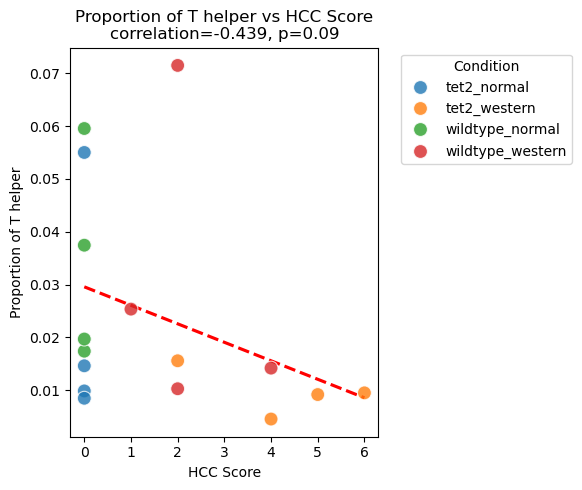

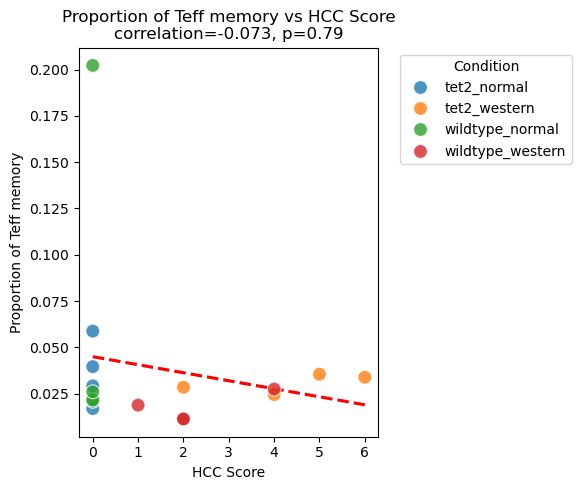

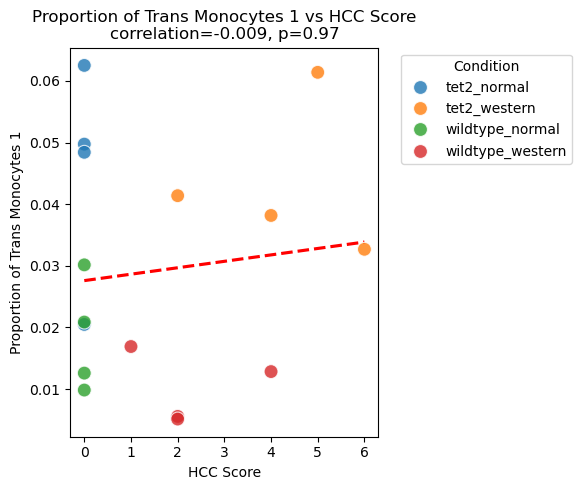

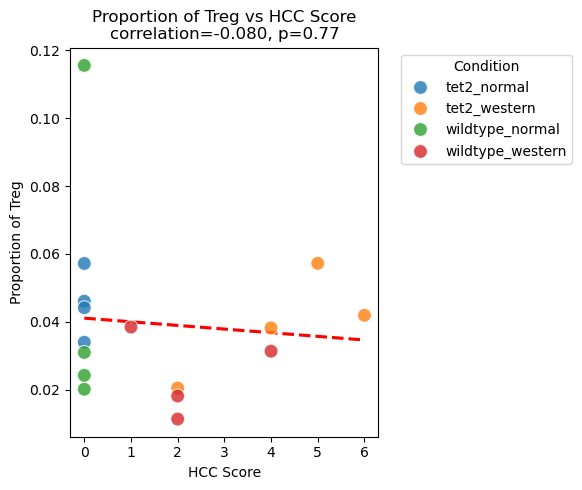

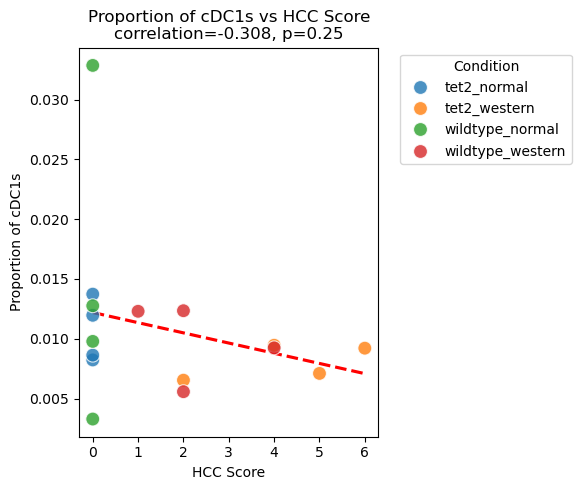

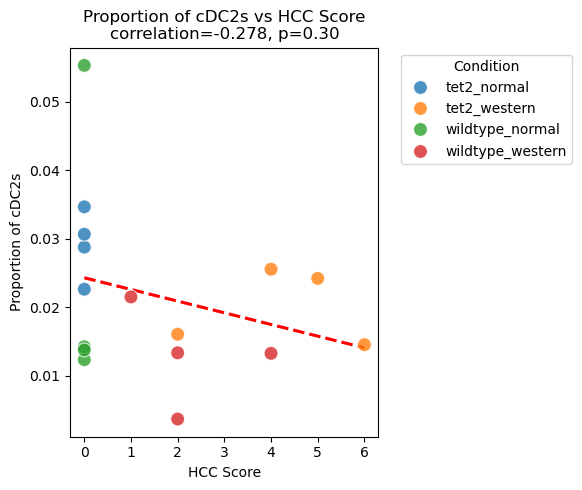

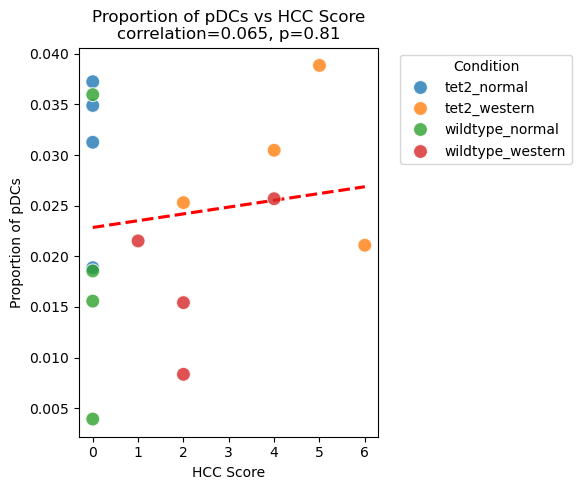

In [40]:
def plot_cell_type_correlation(cell_props_df, cell_type, score_dict, obs_df):
    if cell_type not in cell_props_df.columns:
        return

    temp_df = cell_props_df[[cell_type]].copy()
    temp_df['hcc_score'] = temp_df.index.map(score_dict)
    
    condition_map = obs_df.drop_duplicates('orig.ident').set_index('orig.ident')['condition_full']
    temp_df['condition'] = temp_df.index.map(condition_map)
    
    temp_df = temp_df.dropna(subset=['hcc_score', 'condition'])
    
    corr, p_val = spearmanr(temp_df['hcc_score'], temp_df[cell_type])
    
    plt.figure(figsize=(6, 5))
    
    sns.regplot(data=temp_df, x='hcc_score', y=cell_type, 
                ci=None, scatter=False, line_kws={'color':'red', 'ls':'--', 'zorder':1})
    
    sns.scatterplot(data=temp_df, x='hcc_score', y=cell_type, 
                    hue='condition', s=100, alpha=0.8, zorder=2)
    
    plt.title(f"Proportion of {cell_type} vs HCC Score\ncorrelation={corr:.3f}, p={p_val:.2f}")
    plt.xlabel("HCC Score")
    plt.ylabel(f"Proportion of {cell_type}")
    plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

for cell in cell_props.columns:
    plot_cell_type_correlation(cell_props, cell, hcc_scores, adata.obs)

In [5]:
props_df = calculate_proportions(adata.obs, sample_col='condition_full', condition_col='condition')

In [7]:
props_df

celltypist_pred,condition_full,condition,B cells,CTLs,CV and Capsule,Gd,ILCs,Mig cDCs,Monocytes,NK,...,Naive CD4,Naive CD8,Patrolling Monocytes,T helper,Teff memory,Trans Monocytes 1,Treg,cDC1s,cDC2s,pDCs
0,tet2_normal,tn,0.318907,0.293961,0.003379,0.006470,0.007333,0.005967,0.040474,0.013587,...,0.003810,0.056794,0.025090,0.016894,0.031919,0.047592,0.042416,0.011431,0.030554,0.032998
1,tet2_western,tw,0.339871,0.321972,0.002263,0.005212,0.008092,0.002880,0.035523,0.012070,...,0.006309,0.064600,0.015979,0.010972,0.030106,0.042038,0.034906,0.007818,0.018927,0.027568
2,wildtype_normal,wn,0.514613,0.059947,0.001650,0.009978,0.009271,0.003850,0.035119,0.023413,...,0.008171,0.095380,0.030405,0.035748,0.045176,0.017520,0.035669,0.014299,0.022156,0.018935
3,wildtype_western,ww,0.600334,0.028330,0.001771,0.010525,0.009542,0.002066,0.024789,0.027740,...,0.011607,0.101515,0.029117,0.028822,0.020362,0.011607,0.028428,0.009542,0.013378,0.019969


In [9]:
western_diet_props_df = props_df[~props_df['condition'].isin(['tn', 'wn'])]

In [12]:
from scipy.stats import pearsonr, spearmanr

props_df['hcc_score'] = props_df['orig.ident'].str.lower().map(hcc_scores)

def get_cell_proportion_correlation(props_df): 
    results = {}
    
    # List of cell types is derived from your props_df columns (excluding metadata columns)
    # Based on your image, these start from index 3 onwards
    cell_types = props_df.columns[3:-1] 
    
    
    for cell_type in cell_types:
        # Extract x (hcc_score) and y (cell type proportion)
        x = props_df['hcc_score']
        y = props_df[cell_type]
        
        # Compute Pearson Correlation
        corr, p_val = spearmanr(x, y)
        results[cell_type] = {'r': corr, 'p': p_val}

    summary = pd.DataFrame(results).T
    return summary 


def plot_cell_proportion_correlations(df):
    # Identifying cell type columns (skipping metadata and the hcc_score column itself)
    cell_types = [c for c in df.columns[3:] if c not in ['hcc_score', 'condition', 'orig.ident']]
    
    for cell_type in cell_types:
        plt.figure(figsize=(7, 5))
        
        # 1. Draw the regression line for the overall trend
        sns.regplot(data=df, x='hcc_score', y=cell_type, scatter=False, line_kws={'color': 'black', 'linestyle': '--', 'alpha': 0.5})
        
        sns.scatterplot(data=df, x='hcc_score', y=cell_type, hue='condition', s=100, edgecolor='black')
        
        r, p = spearmanr(df['hcc_score'], df[cell_type])
        
        plt.title(f"{cell_type}\nSpearman r: {r:.3f}, p: {p}")
        plt.xlabel("HCC Score")
        plt.ylabel(f"Proportion of {cell_type}")
        plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, linestyle='--', alpha=0.3)
        plt.tight_layout()
        plt.show()

corr_summary_1 = get_cell_proportion_correlation(props_df)

corr_summary_2 = get_cell_proportion_correlation(western_diet_props_df)

KeyError: 'orig.ident'

## Stacked Barplot of Cell Type Proportions in Each Group Condition

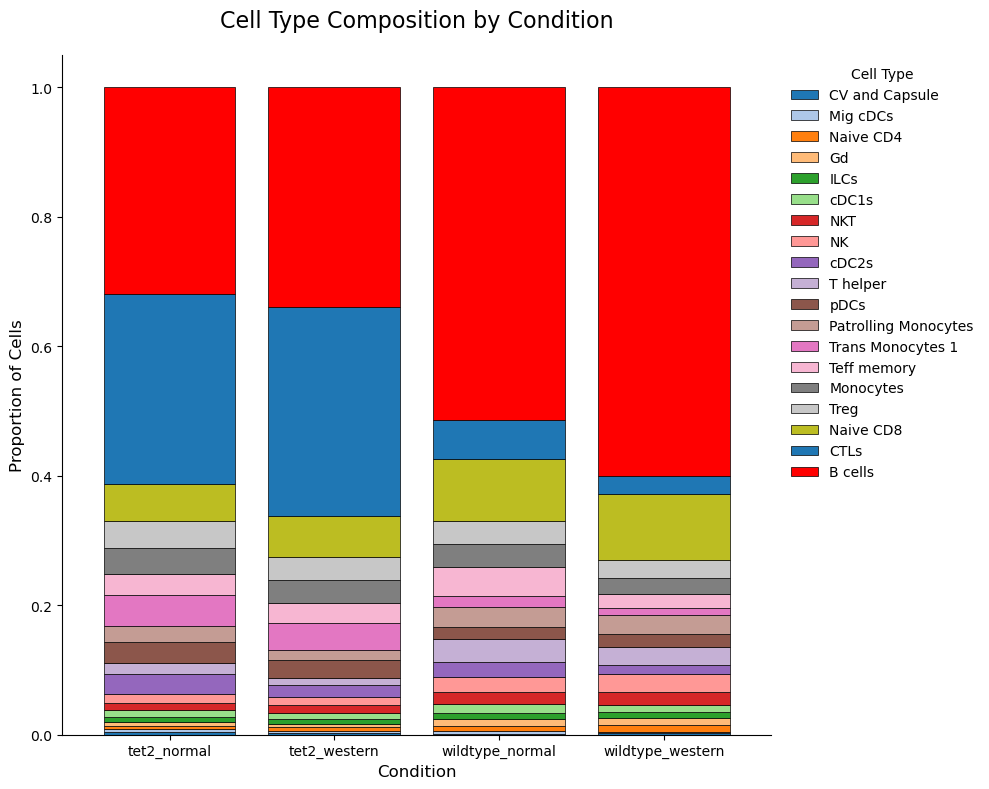

In [5]:
# Calculate Proportions per Condition 
# We group by 'Condition' and 'celltypist_pred' to get the total counts
# Then we reshape it so Cell Types are columns
counts = pd.crosstab(
    index=adata.obs['condition_full'], 
    columns=adata.obs['celltypist_pred']
)

# make sure each row sums up to 1 
props = counts.div(counts.sum(axis=1), axis=0)

# sort the columns (Cell Types) by abundance so the biggest chunks are at the bottom
# makes the plot much easier to read
mean_abundance = props.mean().sort_values(ascending=True).index
props = props[mean_abundance]


# add custom color map to roughly match Noemie's data
color_dict = {
    'B cells': 'red',
    'CTLs': 'tab:blue',
}
# fill in rest of the cell colors randomly
default_palette = sns.color_palette("tab20", len(props.columns))
colors = [color_dict.get(cell_type, default_palette[i]) 
          for i, cell_type in enumerate(props.columns)]

# Plot Stacked Bar Chart 
# We use a large figure size because you have 19+ cell types
ax = props.plot(
    kind='bar', 
    stacked=True, 
    figsize=(10, 8), 
    color=colors,     
    width=0.8,
    edgecolor='black', 
    linewidth=0.5
)


plt.title('Cell Type Composition by Condition', fontsize=16, pad=20)
plt.ylabel('Proportion of Cells', fontsize=12)
plt.xlabel('Condition', fontsize=12)
plt.xticks(rotation=0) # Keep x-axis labels (tw, ww) horizontal

# nove the Legend outside
# bbox_to_anchor=(1.01, 1) puts it just to the right of the top-right corner
plt.legend(
    title='Cell Type', 
    bbox_to_anchor=(1.01, 1), 
    loc='upper left',
    frameon=False
)

# remove top and right borders for a cleaner look
sns.despine()

plt.tight_layout()
plt.show()

## Check if Counts/Proportions of Cell Types Between 4 Conditions is Statistically Sig.

In [18]:
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np

count_df = pd.crosstab(adata.obs['condition_full'], adata.obs['celltypist_pred'])
chi2, p, dof, expected = chi2_contingency(count_df)

In [31]:
# Count cells per sample per cell type
counts = adata.obs.groupby(['orig.ident', 'celltypist_pred']).size().unstack(fill_value=0)

# Convert to proportions (each row sums to 1)
props = counts.div(counts.sum(axis=1), axis=0)

# Add condition label back
props['condition'] = props.index.str[:2]

In [39]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

def compare_conditions(props_df, cond1, cond2):
    cell_types = [c for c in props_df.columns if c != 'condition']
    
    cond1_data = props_df[props_df['condition'] == cond1]
    cond2_data = props_df[props_df['condition'] == cond2]
    
    results = []
    for ct in cell_types:
        stat, p = mannwhitneyu(cond1_data[ct], cond2_data[ct], alternative='two-sided')
        results.append({
            'cell_type': ct,
            'mean_prop_cond1': cond1_data[ct].mean(),
            'mean_prop_cond2': cond2_data[ct].mean(),
            'log2FC': np.log2((cond2_data[ct].mean() + 1e-6) / (cond1_data[ct].mean() + 1e-6)),
            'p_value': p
        })
    
    results_df = pd.DataFrame(results)
    _, results_df['p_adj'], _, _ = multipletests(results_df['p_value'], method='fdr_bh')
    results_df['significant'] = results_df['p_adj'] < 0.05
    
    return results_df.sort_values('p_adj')

results = compare_conditions(props, 'tn', 'tw')
results

,cell_type,mean_prop_cond1,mean_prop_cond2,log2FC,p_value,p_adj,significant
11,Patrolling Monocytes,0.024721,0.016240,-0.606147,0.028571,0.542857,False
5,Mig cDCs,0.006515,0.002897,-1.168904,0.114286,0.723810,False
17,cDC2s,0.029199,0.020111,-0.537899,0.114286,0.723810,False
4,ILCs,0.007714,0.008842,0.196718,0.685714,0.868571,False
7,NK,0.012840,0.012027,-0.094353,0.485714,0.868571,False
9,Naive CD4,0.004193,0.006065,0.532355,0.342857,0.868571,False
8,NKT,0.011000,0.012193,0.148620,0.485714,0.868571,False
3,Gd,0.007282,0.005011,-0.539115,0.685714,0.868571,False
12,T helper,0.022003,0.009709,-1.180213,0.485714,0.868571,False
13,Teff memory,0.036150,0.030597,-0.240590,0.685714,0.868571,False


In [40]:
print(props.groupby('condition').size())

condition
tn    4
tw    4
wn    4
ww    4
dtype: int64
